In [1]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("StudentsPerformance.csv")

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
df.shape

(1000, 8)

In [13]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [14]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [15]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["total_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [19]:
df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


In [20]:
df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


In [21]:
df[["math score", "reading score", "writing score"]].corr().round(2)

,math score,reading score,writing score
math score,1.00,0.82,0.80
reading score,0.82,1.00,0.95
writing score,0.80,0.95,1.00


In [22]:
df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [23]:
df["total_score"].describe().round(2)

,total_score
count,1000.00
mean,203.31
std,42.77
min,27.00
25%,175.00
50%,205.00
75%,233.00
max,300.00


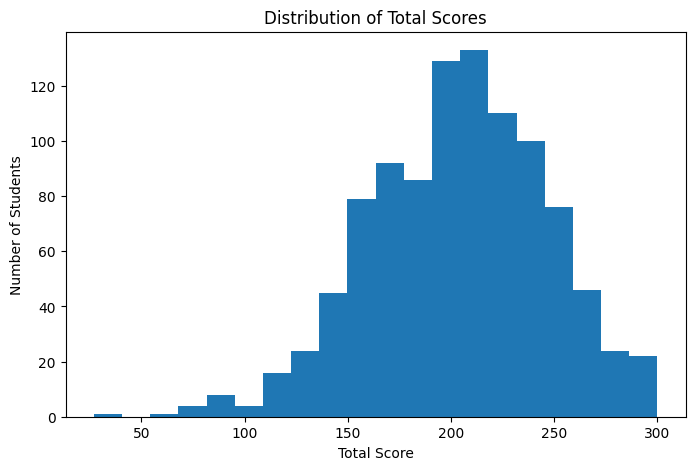

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["total_score"], bins=20)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

<Figure size 1000x600 with 0 Axes>

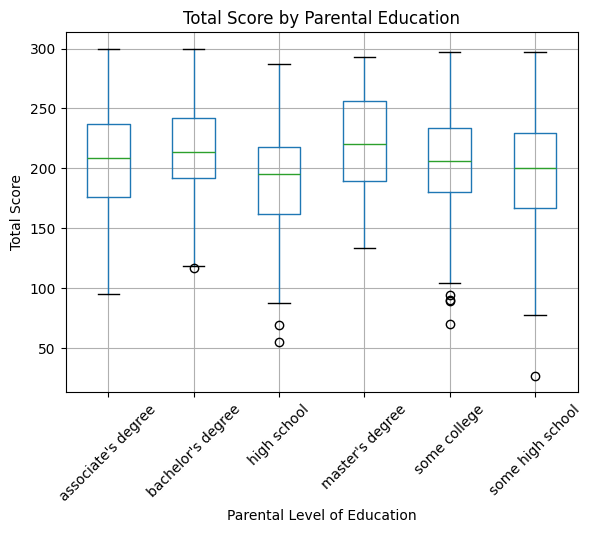

In [25]:
plt.figure(figsize=(10,6))
df.boxplot(column="total_score", by="parental level of education", rot=45)

plt.title("Total Score by Parental Education")
plt.suptitle("")
plt.xlabel("Parental Level of Education")
plt.ylabel("Total Score")

plt.show()

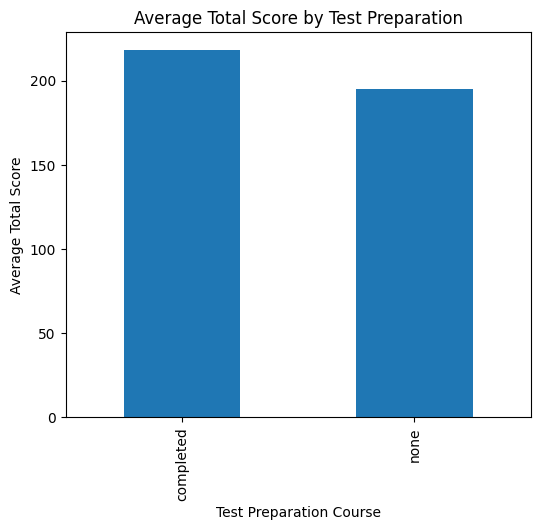

In [26]:
df.groupby("test preparation course")["total_score"].mean().plot(
    kind="bar", figsize=(6,5)
)

plt.title("Average Total Score by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Total Score")

plt.show()

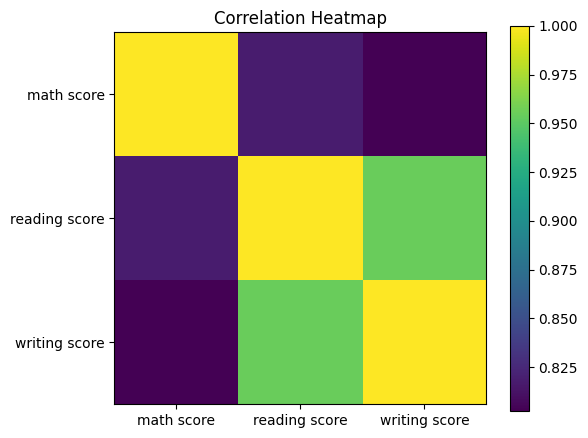

In [27]:
corr = df[["math score", "reading score", "writing score"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr)

plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)

plt.colorbar()
plt.title("Correlation Heatmap")

plt.show()

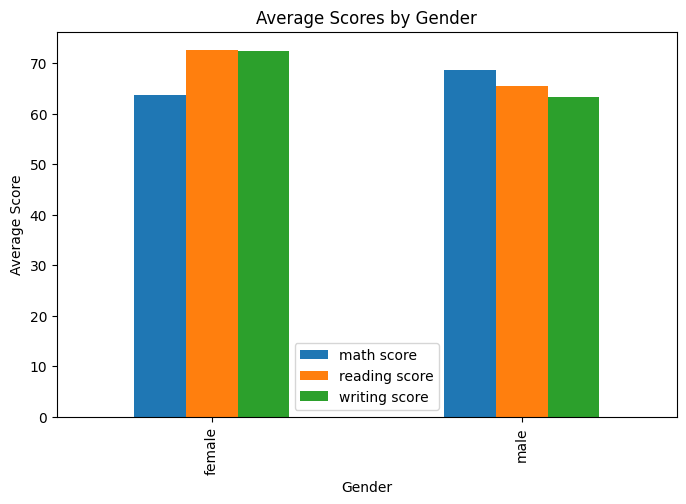

In [28]:
df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean().plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

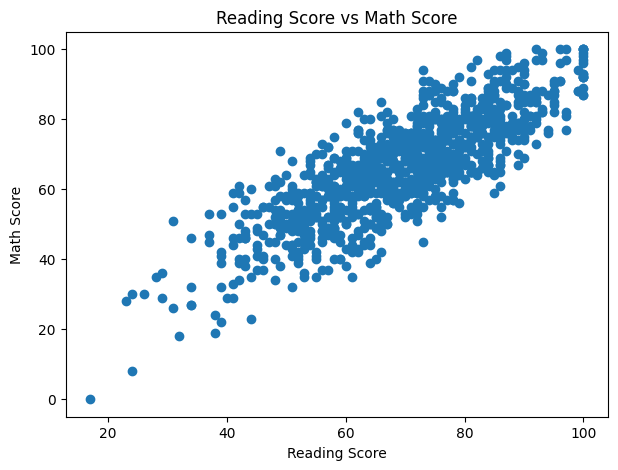

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["reading score"],
    df["math score"]
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

In [30]:
at_risk = df[
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
]

print("Number of at-risk students:", len(at_risk))

Number of at-risk students: 188


In [31]:
at_risk.groupby("gender").size()

,0
gender,
female,89
male,99


<Figure size 1000x600 with 0 Axes>

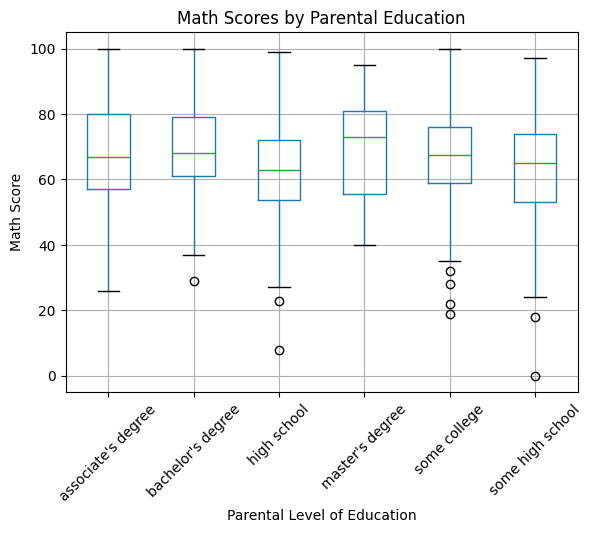

In [32]:
plt.figure(figsize=(10, 6))
df.boxplot(column="math score", by="parental level of education", rot=45)

plt.title("Math Scores by Parental Education")
plt.suptitle("")
plt.xlabel("Parental Level of Education")
plt.ylabel("Math Score")

plt.show()